<a href="https://colab.research.google.com/github/Amri1003/Machine_Learning_Projects/blob/main/K-meansClustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print('imported')

imported


In [ ]:
# load the data

url='https://raw.githubusercontent.com/npradaschnor/Pima-Indians-Diabetes-Dataset/refs/heads/master/diabetes.csv'

data=pd.read_csv(url)

data.head()






,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
# check for missing va;ues
data.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
data.describe()
# we are getting zeroes instead of null

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


<Axes: ylabel='BloodPressure'>

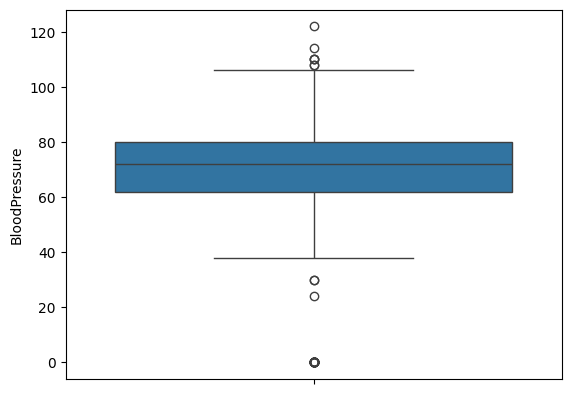

In [ ]:
# creating box plot for blood pressure
sns.boxplot(data['BloodPressure'])

In [ ]:
data['Outcome'].value_counts()






,count
Outcome,
0,500
1,268


In [ ]:
# col. with zero value
col_with_zero=['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

In [ ]:
# replace all data_col with median of values

for col in col_with_zero:

  median_value=data[col].median()

  data[col]=data[col].replace(0,median_value)






In [ ]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,27.334635,94.652344,32.450911,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,9.229014,105.547598,6.875366,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,23.000000,30.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,31.250000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
# Create dependent and independent variable
X=data.iloc[:,:-1]

y=data.iloc[:,-1]






In [ ]:
# perform splitting

from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)






In [ ]:
from sklearn.preprocessing import StandardScaler

sc=StandardScaler()

X_train=sc.fit_transform(X_train)

X_test=sc.transform(X_test)






In [ ]:
from sklearn.ensemble import BaggingClassifier

from sklearn.tree import DecisionTreeClassifier

estimator=DecisionTreeClassifier()

#num_trees=100 oob_score=true  also giving warning

bagging_model=BaggingClassifier(estimator=estimator,random_state=42)

bagging_model.fit(X_train,y_train)

print('Training Completed')






Training Completed


In [ ]:
from sklearn.metrics import accuracy_score,classification_report




y_pred=bagging_model.predict(X_test)

print('Accuracy_score',accuracy_score(y_test,y_pred))






Accuracy_score 0.7359307359307359


In [ ]:
print(classification_report(y_test,y_pred))






              precision    recall  f1-score   support

           0       0.78      0.83      0.80       151
           1       0.63      0.56      0.60        80

    accuracy                           0.74       231
   macro avg       0.71      0.70      0.70       231
weighted avg       0.73      0.74      0.73       231



In [ ]:
# changing the model with num_trees with decision tree classifier
from sklearn.ensemble import BaggingClassifier

from sklearn.tree import DecisionTreeClassifier

estimator=DecisionTreeClassifier()

num_trees=100

bagging_model=BaggingClassifier(estimator=estimator,n_estimators=num_trees,random_state=42)

bagging_model.fit(X_train,y_train)

print('Training Completed')


Training Completed


In [ ]:
from sklearn.metrics import accuracy_score,classification_report




y_pred=bagging_model.predict(X_test)

print('Accuracy_score',accuracy_score(y_test,y_pred))






Accuracy_score 0.7402597402597403


In [ ]:
# not much changed after passing trees value
# now changing the classifier to Logic reg
from sklearn.ensemble import BaggingClassifier

from sklearn.linear_model import LogisticRegression

estimator=LogisticRegression()

num_estimators=100

bagging_model=BaggingClassifier(estimator=estimator,n_estimators=num_estimators,random_state=42)

bagging_model.fit(X_train,y_train)

print('Training Completed')






Training Completed


In [ ]:
y_pred=bagging_model.predict(X_test)

print('Accuracy_score',accuracy_score(y_test,y_pred))






Accuracy_score 0.7445887445887446


In [ ]:
print(classification_report(y_test,y_pred))






              precision    recall  f1-score   support

           0       0.79      0.82      0.81       151
           1       0.64      0.60      0.62        80

    accuracy                           0.74       231
   macro avg       0.72      0.71      0.71       231
weighted avg       0.74      0.74      0.74       231



Apply Random Forest Classifier

In [ ]:
#  both are giving same accuracy
# now applying random forest
from sklearn.ensemble import RandomForestClassifier

rf=RandomForestClassifier(random_state=42)







In [ ]:
rf.fit(X_train,y_train)






RandomForestClassifier(random_state=42)

In [ ]:
y_pred=rf.predict(X_test)






In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print('accuracy',accuracy_score(y_test,y_pred))






accuracy 0.7748917748917749


In [ ]:
# do accuracy check for training
y_pred_train=rf.predict(X_train)

print('Training accuracy',accuracy_score(y_train,y_pred_train))






Training accuracy 1.0


In [ ]:
# its overfitted so applying hyperparameter
# now  re-applying random forest with max_depth=3
from sklearn.ensemble import RandomForestClassifier

rf=RandomForestClassifier(random_state=42,max_depth=3)
rf.fit(X_train,y_train)
y_pred=rf.predict(X_test)
from sklearn.metrics import accuracy_score, classification_report

print('accuracy after max_depth=3',accuracy_score(y_test,y_pred))








accuracy after max_depth=3 0.7532467532467533


In [ ]:
# apply grid searchcv on random forest

from sklearn.model_selection import GridSearchCV

rf=RandomForestClassifier(random_state=42)

# Define the parameter grid for RandomForestClassifier

param_grid = {

    'n_estimators': [100],

    'max_depth': [3, 5, 7, None],

    'min_samples_split': [2, 5, 10],

    'min_samples_leaf': [1, 2, 4],

    'bootstrap': [True, False]

}

# Initialize GridSearchCV

grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1, scoring='accuracy')

print("GridSearchCV initialized with parameter grid and cross-validation.")






GridSearchCV initialized with parameter grid and cross-validation.


In [ ]:
# Fit GridSearchCV to the training data

grid_search.fit(X_train, y_train)

print("GridSearchCV fitting completed.")

# Print the best parameters found by GridSearchCV

print("Best parameters found: ", grid_search.best_params_)

# Get the best estimator

best_rf = grid_search.best_estimator_

# Make predictions with the best estimator

y_pred_grid = best_rf.predict(X_test)

y_pred_train_grid = best_rf.predict(X_train)

# Evaluate the best estimator

print('Test accuracy with best parameters:', accuracy_score(y_test, y_pred_grid))

print('Train accuracy with best parameters:', accuracy_score(y_train, y_pred_train_grid))

print('Classification Report with best parameters:\n', classification_report(y_test, y_pred_grid))






GridSearchCV fitting completed.
Best parameters found:  {'bootstrap': True, 'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Test accuracy with best parameters: 0.7402597402597403
Train accuracy with best parameters: 0.9515828677839852
Classification Report with best parameters:
               precision    recall  f1-score   support

           0       0.80      0.81      0.80       151
           1       0.63      0.61      0.62        80

    accuracy                           0.74       231
   macro avg       0.71      0.71      0.71       231
weighted avg       0.74      0.74      0.74       231



In [ ]:
# change tress number etc


Boosting Technique

1.combine the multiple weak learners/models to form a strong learners.

Sequential Learning--iterative process
Weights--higher weight to misclassified sample.
Final Pred-combine all outputs.





#AdaBoost, an abbreviation for adaptive boosting,

stands as one of the leading boosting algorithms with widespread adoption. It focuses on classification problems, aiming to transform a collection of weak classifiers into a single strong classifier. It increases the weights of misclassified instances, directing subsequent classifiers to pay more attention to challenging cases.

The AdaBoost algorithm follows these steps:

    

1.  Initially, the algorithm assigns equal weights to all observations in the dataset.

2.  A model is constructed using a subset of the data.

3.  Predictions are made on the entire dataset using this model.

4.  The algorithm computes errors by comparing these predictions to the actual values.

5.  In the subsequent model creation, the algorithm assigns higher weights to incorrectly predicted data points.

6.  Weights are determined based on error values, where higher errors result in heavier observation weights.

7.  This iterative process continues until the error function stabilizes or the algorithm reaches the maximum limit of estimators.






In [ ]:
# importing another data
data=pd.read_csv("breast-cancer-wisconsin.data",header=None)






In [ ]:
data.columns = ['Sample code', 'Clump Thickness', 'Uniformity of Cell Size', 'Uniformity of Cell Shape',

                'Marginal Adhesion', 'Single Epithelial Cell Size', 'Bare Nuclei', 'Bland Chromatin',

                'Normal Nucleoli', 'Mitoses','Class']






In [ ]:
data.info()






<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Sample code                  699 non-null    int64 
 1   Clump Thickness              699 non-null    int64 
 2   Uniformity of Cell Size      699 non-null    int64 
 3   Uniformity of Cell Shape     699 non-null    int64 
 4   Marginal Adhesion            699 non-null    int64 
 5   Single Epithelial Cell Size  699 non-null    int64 
 6   Bare Nuclei                  699 non-null    object
 7   Bland Chromatin              699 non-null    int64 
 8   Normal Nucleoli              699 non-null    int64 
 9   Mitoses                      699 non-null    int64 
 10  Class                        699 non-null    int64 
dtypes: int64(10), object(1)
memory usage: 60.2+ KB


In [ ]:
data.drop(['Sample code'],axis=1,inplace=True)






In [ ]:
data=data.replace('?',np.nan)






In [ ]:
# change data type

data['Bare Nuclei']=pd.to_numeric(data['Bare Nuclei']).fillna(0).astype('int64')






In [ ]:
data['Class'].value_counts()






,count
Class,
2,458
4,241


In [ ]:
# class 2 --Non cancer, 4-Cancerours




data['Class']=data['Class'].replace({2:0,4:1})






In [ ]:

# imputer is a class in skilearn which can replace missing value
# by median etc. helpful for new data given by user
from sklearn.impute import SimpleImputer

from sklearn.preprocessing import MinMaxScaler

from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline

from sklearn.model_selection import KFold,cross_val_score

from sklearn.ensemble import AdaBoostClassifier






In [ ]:
# split the data

X=data.drop('Class',axis=1)

y=data['Class']






In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)






In [ ]:
# create a pipeline

adaboost_pipeline=Pipeline([('imputer',SimpleImputer(strategy='mean')),

                           ('scaler',MinMaxScaler(feature_range=(0,1))),

                            ('classifier',AdaBoostClassifier(n_estimators=100,random_state=42))])






In [ ]:
adaboost_pipeline.fit(X_train,y_train)

y_pred=adaboost_pipeline.predict(X_test)

print('test accuracy',accuracy_score(y_test,y_pred))

y_pred_train=adaboost_pipeline.predict(X_train)

print('train accuracy',accuracy_score(y_train,y_pred_train))






test accuracy 0.9571428571428572
train accuracy 0.9767441860465116


In [ ]:
# define K-fold

kfold=KFold(n_splits=10,random_state=42,shuffle=True)

adaboost_results=cross_val_score(adaboost_pipeline,X_train,y_train,cv=kfold)

print('Cross validation score',adaboost_results.mean())






Cross validation score 0.9533116883116882


In [ ]:
print(classification_report(y_test,y_pred))






              precision    recall  f1-score   support

           0       0.96      0.98      0.97        95
           1       0.95      0.91      0.93        45

    accuracy                           0.96       140
   macro avg       0.96      0.95      0.95       140
weighted avg       0.96      0.96      0.96       140



Gradient boosting is also known as gradient tree boosting, stochastic gradient boosting (an extension), and gradient boosting machines, or GBM for short.

Ensembles are constructed from decision tree models. Trees are added one at a time to the ensemble and fit to correct the prediction errors made by prior models Gradient Boosting involves three main components:

• Loss Function: The choice of loss function depends on the type of problem being solved (e.g., regression, classification). The goal is to find a model that minimizes the loss function.

• Weak Learners: Gradient Boosting uses decision trees as the default weak learner. These trees are usually of a fixed size and depth and are created one at a time.

• Additive Model: Instead of adjusting the weights of data points like AdaBoost, Gradient Boosting fits new models to the residual errors made by previous models. Essentially, each new model is built on the errors of the whole ensemble so far.






In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

# define K-fold

kfold=KFold(n_splits=10,random_state=42,shuffle=True)

# create a pipeline

gb_pipeline=Pipeline([('imputer',SimpleImputer(strategy='mean')),

                           ('scaler',MinMaxScaler(feature_range=(0,1))),

                            ('classifier',GradientBoostingClassifier(n_estimators=100,random_state=42))])



gb_results=cross_val_score(gb_pipeline,X_train,y_train,cv=kfold)

print('Cross validation score',gb_results.mean())






Cross validation score 0.9534090909090907


In [ ]:
gb_pipeline.fit(X_train,y_train)

y_pred=gb_pipeline.predict(X_test)

print('test accuracy',accuracy_score(y_test,y_pred))

y_pred_train=gb_pipeline.predict(X_train)

print('train accuracy',accuracy_score(y_train,y_pred_train))






test accuracy 0.9642857142857143
train accuracy 1.0


XGBoost

XGBoost - Extreme Gradinet Boosting Standalond Library

Optimized Gradient Boosting-like GB, but introduces optimization improve speed and accuracy.

Regularization-L1 (Lasso), L2(Ridge) to handle overfitting.

Parallel processing- perform computation across multiple cores

Tree Pruning-

Handle missing data

Out of core Computing---Effiently handle large datasets that do not fit in memory

Custom Loss function

sparsity Awareness--Efficient handle one hot encoded features

cache






In [ ]:
!pip install xgboost






In [ ]:
from xgboost import XGBClassifier

xgb=XGBClassifier()






In [ ]:
# define K-fold

kfold=KFold(n_splits=10,random_state=42,shuffle=True)

# create a pipeline

xgb_pipeline=Pipeline([('imputer',SimpleImputer(strategy='mean')),

                           ('scaler',MinMaxScaler(feature_range=(0,1))),

                            ('classifier',XGBClassifier(n_estimators=100,random_state=42))])



xgb_results=cross_val_score(xgb_pipeline,X_train,y_train,cv=kfold)

print('Cross validation score',xgb_results.mean())






Cross validation score 0.9569805194805193


In [ ]:
xgb_pipeline.fit(X_train,y_train)

y_pred=xgb_pipeline.predict(X_test)

print('test accuracy',accuracy_score(y_test,y_pred))

y_pred_train=xgb_pipeline.predict(X_train)

print('train accuracy',accuracy_score(y_train,y_pred_train))






test accuracy 0.95
train accuracy 1.0


In [ ]:
# define K-fold

kfold=KFold(n_splits=10,random_state=42,shuffle=True)

# create a pipeline

xgb_pipeline=Pipeline([('imputer',SimpleImputer(strategy='mean')),

                           ('scaler',MinMaxScaler(feature_range=(0,1))),

                            ('classifier',XGBClassifier(

    n_estimators=100,             # Number of boosting rounds

    learning_rate=0.1,            # Step size shrinking

    max_depth=6,                  # Maximum depth of trees

    subsample=0.8,                # Fraction of data used for each tree

    colsample_bytree=0.8,         # Fraction of features used for each tree

    gamma=0.1,                    # Minimum loss reduction to make a further partition

    reg_lambda=1,                 # L2 regularization

    reg_alpha=0,                  # L1 regularization

    random_state=42               # For reproducibility

))])



xgb_results=cross_val_score(xgb_pipeline,X_train,y_train,cv=kfold)

print('Cross validation score',gb_results.mean())






Cross validation score 0.9534090909090907


In [ ]:
xgb_pipeline.fit(X_train,y_train)

y_pred=xgb_pipeline.predict(X_test)

print('test accuracy',accuracy_score(y_test,y_pred))

y_pred_train=xgb_pipeline.predict(X_train)

print('train accuracy',accuracy_score(y_train,y_pred_train))






test accuracy 0.9571428571428572
train accuracy 0.9964221824686941


In [ ]:
!pip install catboost






   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.7 MB/s eta 0:00:00


In [ ]:
from catboost import CatBoostClassifier






In [ ]:
# define K-fold

kfold=KFold(n_splits=10,random_state=42,shuffle=True)

# create a pipeline

cb_pipeline=Pipeline([('imputer',SimpleImputer(strategy='mean')),

                           ('scaler',MinMaxScaler(feature_range=(0,1))),

                            ('classifier',CatBoostClassifier(n_estimators=100,random_state=42,verbose=0))])



cb_results=cross_val_score(cb_pipeline,X_train,y_train,cv=kfold)

print('Cross validation score',cb_results.mean())






Cross validation score 0.9640909090909091


In [ ]:
cb_pipeline.fit(X_train,y_train)

y_pred=cb_pipeline.predict(X_test)

print('test accuracy',accuracy_score(y_test,y_pred))

y_pred_train=cb_pipeline.predict(X_train)

print('train accuracy',accuracy_score(y_train,y_pred_train))






test accuracy 0.9642857142857143
train accuracy 0.9767441860465116


In [ ]:
df1={

    'Feature1':['A','B','C','A','B','C','B','C','A','B'],

    'Feature2':[1,2,1,2,1,2,1,2,1,2],

    'Class':[0,1,0,1,0,1,0,1,0,1]

}






In [ ]:
df=pd.DataFrame(df1)

df






,Feature1,Feature2,Class
0,A,1,0
1,B,2,1
2,C,1,0
3,A,2,1
4,B,1,0
5,C,2,1
6,B,1,0
7,C,2,1
8,A,1,0
9,B,2,1


In [ ]:
X=df.drop(columns=['Class'])

y=df['Class']






In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)






In [ ]:
cat_feature=['Feature1']






In [ ]:
catboost=CatBoostClassifier(iterations=100,learning_rate=0.1,depth=3,cat_features=cat_feature,verbose=0)






In [ ]:
catboost.fit(X_train,y_train)






CatBoostClassifier(cat_features=['Feature1'], depth=3, iterations=100, learning_rate=0.1, verbose=0)

In [ ]:
y_pred=catboost.predict(X_test)

y_pred






array([0, 1])

In [ ]:
accuracy_score(y_test,y_pred)






1.0